# Cosmological Angular Power Spectra + MCMC
### With IPython Timing & Profiling (`%time`, `%timeit`, `%prun`, `%lprun`, `%memit`, `%mprun`)

## 0. Imports & Setup

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging
import baccoemu
from emantis.matter_power_spectrum import NonLinearMGBoostEmulator
from scipy.interpolate import interp1d, RectBivariateSpline
from scipy.integrate import simpson, cumulative_trapezoid
import os
from contextlib import redirect_stdout, redirect_stderr
import emcee
import corner
import h5py

warnings.simplefilter("ignore")
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)

## 1. Configuration

In [35]:
class Config:
    COSMO_PARAMS = {
        "Omega_m": 0.315,
        "Omega_b": 0.05,
        "h": 0.67,
        "n_s": 0.96,
        "sigma8": 0.83,
        "M_nu": 0.0,
        "w0": -1.0,
        "wa": 0.0,
        "aexp": 1.0,
    }
    c = 299792.458
    Z_MIN = 0.01
    Z_MAX = 1.5
    N_Z = 500
    N_Z_CHI = 2000
    Z0_GALAXY = 0.3
    ELL_MIN = 10
    ELL_MAX = 2000
    N_ELL = 50
    BIAS_B0 = 2.0
    alpha = 2.225
    FR_VALUES = [4, 5, 6]
    BACCO_K_MIN = -2
    BACCO_K_MAX = None
    BACCO_N_K = 200
    EMANTIS_VERBOSE = False
    FIGURE_SIZE = (14, 10)
    K_MIN_SAFETY = 1.1
    K_MAX_SAFETY = 0.9

## 2. Core Functions

In [36]:
def hubble_function(z, H0, Om_m, Om_lambda):
    z = np.asarray(z)
    return H0 * np.sqrt(
        Om_m * (1 + z) ** 3
        + (1 - Om_m - Om_lambda) * (1 + z) ** 2
        + Om_lambda
    )


def build_chi_interpolator(H0, Om_m, Om_lambda, n=None):
    n = n or Config.N_Z_CHI
    z_dense = np.linspace(0.0, Config.Z_MAX * 1.05, n)
    Hz = hubble_function(z_dense, H0, Om_m, Om_lambda)
    chi_dense = np.concatenate(
        [[0.0], cumulative_trapezoid(Config.c / Hz, z_dense)]
    )
    return interp1d(z_dense, chi_dense, kind="cubic",
                    bounds_error=False, fill_value="extrapolate")


def compute_Omega_z(z, H0, Om_m, Om_lambda):
    num = Om_m * (1 + z) ** 3
    den = Om_m * (1 + z) ** 3 + (1 - Om_m - Om_lambda) * (1 + z) ** 2 + Om_lambda
    return num / den


def compute_lambda_z(z, H0, Om_m, Om_lambda):
    num = Om_lambda
    den = Om_m * (1 + z) ** 3 + (1 - Om_m - Om_lambda) * (1 + z) ** 2 + Om_lambda
    return num / den


def growth_function_g(z, H0, Om_m, Om_lambda):
    Omega_z = compute_Omega_z(z, H0, Om_m, Om_lambda)
    lambda_z = compute_lambda_z(z, H0, Om_m, Om_lambda)
    den = Omega_z ** (4 / 7) - lambda_z + (1 + Omega_z / 2) * (1 + lambda_z / 70)
    return (5 * Omega_z / 2) * (1 / den)


def growth_factor_D(z, H0, Om_m, Om_lambda):
    z = np.asarray(z)
    g_z = growth_function_g(z, H0, Om_m, Om_lambda)
    g_0 = growth_function_g(0.0, H0, Om_m, Om_lambda)
    return (g_z / (1.0 + z)) / g_0


def bias_function(z, H0, Omega_m, Omega_lambda, b0=1.0):
    D_z = growth_factor_D(z, H0, Omega_m, Omega_lambda)
    D_0 = growth_factor_D(0.0, H0, Omega_m, Omega_lambda)
    return b0 / (D_z / D_0 + 1e-30)


def cmb_lensing_kernel_vec(z_grid, z_star, H0, Om_m, Om_lambda, chi_of_z):
    Hz = hubble_function(z_grid, H0, Om_m, Om_lambda)
    prefactor = (3 * Om_m * H0 ** 2) / (2 * Config.c * Hz)
    chi_z = chi_of_z(z_grid)
    chi_star = float(chi_of_z(z_star))
    return prefactor * (1 + z_grid) * chi_z * (chi_star - chi_z) / chi_star


def galaxy_lensing_kernel_vec(z_grid, dNdz_arr, bias_arr, H0, Om_m, Om_lambda, chi_of_z):
    chi_z = chi_of_z(z_grid)
    Hz = hubble_function(z_grid, H0, Om_m, Om_lambda)
    alpha_minus1 = Config.alpha - 1.0
    f_A = alpha_minus1 * dNdz_arr
    f_B = alpha_minus1 * dNdz_arr / (chi_z + 1e-30)

    def suffix_trapz(f, z):
        ct = cumulative_trapezoid(f[::-1], z[::-1], initial=0.0)
        return ct[::-1]

    A_suffix = suffix_trapz(f_A, z_grid)
    B_suffix = suffix_trapz(f_B, z_grid)
    mag_integral = A_suffix - chi_z * B_suffix
    mu_prefactor = (3 * Om_m * H0 ** 2) / (2 * Config.c * Hz) * (1 + z_grid) * chi_z
    return bias_arr * dNdz_arr + mu_prefactor * mag_integral

In [37]:
def initialize_bacco_emulator(params, k_min=-2, k_max=None, n_k=200, verbose=False):
    with open(os.devnull, "w") as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            emulator = baccoemu.Matter_powerspectrum(verbose=verbose)
            if k_max is None:
                k_max = np.log10(emulator.emulator["nonlinear"]["k"].max())
            k = np.logspace(k_min, k_max, num=n_k)
    return emulator, k


def initialize_emantis_emulator(verbose=False):
    return NonLinearMGBoostEmulator(verbose=verbose)


def _bacco_params(params):
    return {
        "omega_cold": params["Omega_m"] - params["Omega_b"],
        "sigma8_cold": params["sigma8"],
        "omega_baryon": params["Omega_b"],
        "ns": params["n_s"],
        "hubble": params["h"],
        "neutrino_mass": params.get("M_nu", 0.0),
        "w0": params.get("w0", -1.0),
        "wa": params.get("wa", 0.0),
    }


def _emantis_params(params, logfR0):
    return {
        "Omega_m": params["Omega_m"],
        "Omega_b": params["Omega_b"],
        "h": params["h"],
        "n_s": params["n_s"],
        "sigma8_lcdm": params["sigma8"],
        "logfR0": logfR0,
    }


def _pk_by_aexp(pk, n_aexp, n_k):
    """Return BACCO output as shape (n_aexp, n_k)."""
    arr = np.asarray(pk)
    arr = np.squeeze(arr)

    if arr.ndim == 1:
        if n_aexp != 1 or arr.shape[0] != n_k:
            raise ValueError(f"Unexpected 1D BACCO P(k) shape {arr.shape} for n_aexp={n_aexp}, n_k={n_k}")
        return arr[None, :]

    if arr.shape == (n_aexp, n_k):
        return arr
    if arr.shape == (n_k, n_aexp):
        return arr.T
    if arr.size == n_aexp * n_k:
        return arr.reshape(n_aexp, n_k)

    raise ValueError(f"Unexpected BACCO P(k) shape {arr.shape}; expected ({n_aexp}, {n_k})")


def _boost_by_aexp_and_model(boost, n_aexp, n_model, n_k):
    """Return e-MANTIS output as shape (n_aexp, n_model, n_k)."""
    arr = np.asarray(boost)
    arr = np.squeeze(arr)

    if arr.ndim == 1:
        if n_aexp != 1 or n_model != 1 or arr.shape[0] != n_k:
            raise ValueError(f"Unexpected 1D e-MANTIS boost shape {arr.shape}")
        return arr[None, None, :]

    if arr.ndim == 2:
        if n_model == 1 and arr.shape == (n_aexp, n_k):
            return arr[:, None, :]
        if n_model == 1 and arr.shape == (n_k, n_aexp):
            return arr.T[:, None, :]
        if n_aexp == 1 and arr.shape == (n_model, n_k):
            return arr[None, :, :]
        if n_aexp == 1 and arr.shape == (n_k, n_model):
            return arr.T[None, :, :]

    if arr.shape == (n_aexp, n_model, n_k):
        return arr
    if arr.shape == (n_model, n_aexp, n_k):
        return np.transpose(arr, (1, 0, 2))
    if arr.size == n_aexp * n_model * n_k:
        return arr.reshape(n_aexp, n_model, n_k)

    raise ValueError(
        f"Unexpected e-MANTIS boost shape {arr.shape}; expected ({n_aexp}, {n_model}, {n_k})"
    )


def _build_logpk_spline_from_pk2d(k, z_grid, pk_2d):
    log_k = np.log(k)
    return RectBivariateSpline(log_k, z_grid, np.log(pk_2d + 1e-50), kx=3, ky=3)


def predict_bacco_pk_grid(emulator, params, k, z_grid):
    """Vectorized BACCO call over all redshifts/scale factors."""
    bp = _bacco_params(params)
    aexp_grid = 1.0 / (1.0 + np.asarray(z_grid))

    with open(os.devnull, "w") as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            _, pk_nl = emulator.get_nonlinear_pk(
                k=k,
                cold=False,
                expfactor=aexp_grid,
                **bp,
            )

    return _pk_by_aexp(pk_nl, n_aexp=len(aexp_grid), n_k=len(k))


def build_pk_spline_gr(emulator, params, k, z_grid):
    pk_by_z = predict_bacco_pk_grid(emulator, params, k, z_grid)
    return _build_logpk_spline_from_pk2d(k, z_grid, pk_by_z.T)


def build_pk_spline_fr(emulator, emantis_emu, params, logfR0, k, z_grid):
    pk_gr_by_z = predict_bacco_pk_grid(emulator, params, k, z_grid)
    aexp_grid = 1.0 / (1.0 + np.asarray(z_grid))
    ep = _emantis_params(params, logfR0)

    with open(os.devnull, "w") as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            boost = emantis_emu.predict_boost(
                ep,
                aexp=aexp_grid,
                k=k,
                squeeze=False,
            )

    boost_by_z = _boost_by_aexp_and_model(boost, n_aexp=len(aexp_grid), n_model=1, n_k=len(k))[:, 0, :]
    pk_fr_by_z = pk_gr_by_z * boost_by_z
    return _build_logpk_spline_from_pk2d(k, z_grid, pk_fr_by_z.T)


def build_pk_splines_fr_many(emulator, emantis_emu, params, logfR0_values, k, z_grid):
    """Vectorized BACCO over z and vectorized e-MANTIS over both z and f(R) values."""
    logfR0_values = list(logfR0_values)
    pk_gr_by_z = predict_bacco_pk_grid(emulator, params, k, z_grid)
    aexp_grid = 1.0 / (1.0 + np.asarray(z_grid))

    ep_many = {
        "Omega_m": params["Omega_m"],
        "Omega_b": params["Omega_b"],
        "h": params["h"],
        "n_s": params["n_s"],
        "sigma8_lcdm": params["sigma8"],
        "logfR0": logfR0_values,
    }

    with open(os.devnull, "w") as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            boost = emantis_emu.predict_boost(
                ep_many,
                aexp=aexp_grid,
                k=k,
                squeeze=False,
            )

    boost_by_z_model = _boost_by_aexp_and_model(
        boost,
        n_aexp=len(aexp_grid),
        n_model=len(logfR0_values),
        n_k=len(k),
    )

    splines = {}
    for i, logfR0 in enumerate(logfR0_values):
        pk_fr_by_z = pk_gr_by_z * boost_by_z_model[:, i, :]
        splines[logfR0] = _build_logpk_spline_from_pk2d(k, z_grid, pk_fr_by_z.T)
    return splines


def compute_Cl_vec(ell_array, pk_spline, z_grid, Wg_vals, Wkappa_vals,
                   chi_vals, H_vals, h, c_light, k_min=None, k_max=None, cross=False):
    chi_h = chi_vals * h
    k_vals = (ell_array[:, None] + 0.5) / chi_h[None, :]
    if k_min is not None:
        k_vals = np.clip(k_vals, k_min, k_max)
    log_P_flat = pk_spline(
        np.log(k_vals).ravel(), np.tile(z_grid, len(ell_array)), grid=False
    )
    P_kz = np.exp(log_P_flat).reshape(len(ell_array), len(z_grid)) / h ** 3
    W_product = (Wkappa_vals * Wg_vals)[None, :] if cross else Wg_vals[None, :] ** 2
    integrand = (H_vals[None, :] / c_light) * W_product * P_kz / chi_vals[None, :] ** 2
    return simpson(integrand, z_grid, axis=1)

## 3. Caching Helpers & MCMC Model

In [38]:
_ROUND = 5
_geo_cache = {}
_pk_cache = {}
_GEO_MAXSIZE = 128
_PK_MAXSIZE = 128


def _evict(cache, maxsize):
    if len(cache) >= maxsize:
        del cache[next(iter(cache))]


def get_geometry(Omega_m, b0, z_grid_local, z_star):
    key = (round(float(Omega_m), _ROUND), round(float(b0), _ROUND))
    if key in _geo_cache:
        return _geo_cache[key]
    H0_loc = Config.COSMO_PARAMS["h"] * 100.0
    Om_m_loc = float(Omega_m)
    Om_lam_loc = 1.0 - Om_m_loc
    chi_of_z_loc = build_chi_interpolator(H0_loc, Om_m_loc, Om_lam_loc)
    chi_loc = chi_of_z_loc(z_grid_local)
    H_loc = hubble_function(z_grid_local, H0_loc, Om_m_loc, Om_lam_loc)
    raw_nz = (2.0 * Config.Z0_GALAXY) * (z_grid_local / Config.Z0_GALAXY) ** 2 \
             * np.exp(-z_grid_local / Config.Z0_GALAXY)
    dNdz_loc = raw_nz / simpson(raw_nz, z_grid_local)
    Wkap_loc = cmb_lensing_kernel_vec(z_grid_local, z_star, H0_loc, Om_m_loc, Om_lam_loc, chi_of_z_loc)
    bias_loc = bias_function(z_grid_local, H0_loc, Om_m_loc, Om_lam_loc, b0=float(b0))
    Wg_loc = galaxy_lensing_kernel_vec(z_grid_local, dNdz_loc, bias_loc, H0_loc, Om_m_loc, Om_lam_loc, chi_of_z_loc)
    result = dict(H0=H0_loc, Om_m=Om_m_loc, Om_lam=Om_lam_loc,
                  chi=chi_loc, H=H_loc, Wkappa=Wkap_loc, Wg=Wg_loc)
    _evict(_geo_cache, _GEO_MAXSIZE)
    _geo_cache[key] = result
    return result


def get_pk_spline(Omega_m, sigma8, logfR0, z_grid_local, bacco_emu, emantis_emu, k):
    key = (round(float(Omega_m), _ROUND), round(float(sigma8), _ROUND), round(float(logfR0), _ROUND))
    if key in _pk_cache:
        return _pk_cache[key]
    params = Config.COSMO_PARAMS.copy()
    params["Omega_m"] = float(Omega_m)
    params["sigma8"] = float(sigma8)
    spline = build_pk_spline_fr(bacco_emu, emantis_emu, params, abs(float(logfR0)), k, z_grid_local)
    _evict(_pk_cache, _PK_MAXSIZE)
    _pk_cache[key] = spline
    return spline


def model_cls_fast(theta, ell_local, z_grid_local, z_star, bacco_emu, emantis_emu, k, k_min_safe, k_max_safe):
    Omega_m, sigma8, b0, logfR0 = theta
    geo = get_geometry(Omega_m, b0, z_grid_local, z_star)
    spline = get_pk_spline(Omega_m, sigma8, logfR0, z_grid_local, bacco_emu, emantis_emu, k)
    shared_kw = dict(
        z_grid=z_grid_local,
        Wg_vals=geo["Wg"], Wkappa_vals=geo["Wkappa"],
        chi_vals=geo["chi"], H_vals=geo["H"],
        h=Config.COSMO_PARAMS["h"], c_light=Config.c,
        k_min=k_min_safe, k_max=k_max_safe,
    )
    Cl_gg = compute_Cl_vec(ell_local, spline, cross=False, **shared_kw)
    Cl_kg = compute_Cl_vec(ell_local, spline, cross=True, **shared_kw)
    return Cl_gg, Cl_kg


def flatten_cls(Cl_gg, Cl_kg):
    return np.concatenate([Cl_gg, Cl_kg])

## 4. Initialize Emulators

We time the initialization of both emulators using `%time` (single execution, no repeat).

In [39]:
PLOT_OUTPUT_DIR = "mcmc_plots"
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

H0 = Config.COSMO_PARAMS["h"] * 100.0
Om_m = Config.COSMO_PARAMS["Omega_m"]
Om_lambda = 1.0 - Om_m
z_star = 1100.0

In [40]:
%time bacco_emu, k = initialize_bacco_emulator(Config.COSMO_PARAMS, k_min=Config.BACCO_K_MIN, k_max=Config.BACCO_K_MAX, n_k=Config.BACCO_N_K, verbose=Config.EMANTIS_VERBOSE)

CPU times: user 14.9 ms, sys: 7.97 ms, total: 22.9 ms
Wall time: 22.3 ms


In [41]:
%time emantis_emu = initialize_emantis_emulator(verbose=Config.EMANTIS_VERBOSE)

k_min_safe = k.min() * Config.K_MIN_SAFETY
k_max_safe = k.max() * Config.K_MAX_SAFETY

CPU times: user 18.4 ms, sys: 3.02 ms, total: 21.5 ms
Wall time: 20.8 ms


## 5. Build Geometry & Kernels

`%timeit` is used for the comoving distance interpolator — a fast, repeatable operation where we want a stable average.

In [42]:
z_grid = np.linspace(Config.Z_MIN, Config.Z_MAX, Config.N_Z)

# %timeit — repeated timing for fast operations
%timeit build_chi_interpolator(H0, Om_m, Om_lambda)

590 μs ± 39.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [43]:
chi_of_z = build_chi_interpolator(H0, Om_m, Om_lambda)
chi_vals = chi_of_z(z_grid)
H_vals = hubble_function(z_grid, H0, Om_m, Om_lambda)

_raw_nz = (2.0 * Config.Z0_GALAXY) * (z_grid / Config.Z0_GALAXY) ** 2 \
          * np.exp(-z_grid / Config.Z0_GALAXY)
dNdz = _raw_nz / simpson(_raw_nz, z_grid)

Wkappa_vals = cmb_lensing_kernel_vec(z_grid, z_star, H0, Om_m, Om_lambda, chi_of_z)
bias_arr = bias_function(z_grid, H0, Om_m, Om_lambda, b0=Config.BIAS_B0)
Wg_vals = galaxy_lensing_kernel_vec(z_grid, dNdz, bias_arr, H0, Om_m, Om_lambda, chi_of_z)

# %timeit on the lensing kernel (vectorised — good candidate for repeated timing)
%timeit cmb_lensing_kernel_vec(z_grid, z_star, H0, Om_m, Om_lambda, chi_of_z)

80.7 μs ± 5.39 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## 6. Build GR Power Spectrum Spline

`%time` is appropriate here — the loop over redshift bins is expensive and we only want one run.

In [44]:
%time pk_spline_gr = build_pk_spline_gr(bacco_emu, Config.COSMO_PARAMS, k, z_grid)

CPU times: user 222 ms, sys: 46.2 ms, total: 269 ms
Wall time: 158 ms


## 7. Compute Angular Power Spectra (GR + f(R))

`%timeit` on `compute_Cl_vec` — fully vectorised, fast, benefits from repeated measurement.

In [45]:
ell = np.logspace(np.log10(Config.ELL_MIN), np.log10(Config.ELL_MAX), Config.N_ELL)
shared = dict(
    z_grid=z_grid, Wg_vals=Wg_vals, Wkappa_vals=Wkappa_vals,
    chi_vals=chi_vals, H_vals=H_vals, h=Config.COSMO_PARAMS["h"],
    c_light=Config.c, k_min=k_min_safe, k_max=k_max_safe,
)

%timeit compute_Cl_vec(ell, pk_spline_gr, cross=False, **shared)

10.6 ms ± 712 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [46]:
Cl_gg_gr = compute_Cl_vec(ell, pk_spline_gr, cross=False, **shared)
Cl_kg_gr = compute_Cl_vec(ell, pk_spline_gr, cross=True, **shared)

### 7a. f(R) spectra — time with `%%time` (multi-line cell)

In [47]:
%%time
fr_results = {"gg": {}, "kg": {}}
pk_splines_fr = build_pk_splines_fr_many(
    bacco_emu,
    emantis_emu,
    Config.COSMO_PARAMS,
    Config.FR_VALUES,
    k,
    z_grid,
)

for logfR0_val, pk_spline_fr in pk_splines_fr.items():
    fr_results["gg"][logfR0_val] = compute_Cl_vec(ell, pk_spline_fr, cross=False, **shared)
    fr_results["kg"][logfR0_val] = compute_Cl_vec(ell, pk_spline_fr, cross=True, **shared)

CPU times: user 330 ms, sys: 43.9 ms, total: 374 ms
Wall time: 281 ms


## 8. Function-Level Profiling with `%prun`

`%prun` profiles every function call inside `build_pk_spline_fr`, showing where execution time is actually spent.

In [48]:
%prun build_pk_spline_fr(bacco_emu, emantis_emu, Config.COSMO_PARAMS, 5, k, z_grid)

         489961 function calls (467378 primitive calls) in 0.290 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    22000    0.034    0.000    0.048    0.000 arrayprint.py:1096(__call__)
 22044/44    0.034    0.000    0.121    0.003 arrayprint.py:855(recurser)
    44000    0.024    0.000    0.024    0.000 {built-in method numpy._core._multiarray_umath.dragon4_positional}
   177695    0.015    0.000    0.015    0.000 {built-in method builtins.len}
    22000    0.014    0.000    0.021    0.000 arrayprint.py:805(_extendLine)
        2    0.014    0.007    0.139    0.070 matter_powerspectrum.py:810(get_linear_pk)
    22000    0.013    0.000    0.040    0.000 arrayprint.py:819(_extendLine_pretty)
        1    0.008    0.008    0.233    0.233 matter_powerspectrum.py:272(_evaluate_nonlinear)
        1    0.008    0.008    0.008    0.008 _fitpack2.py:1620(__init__)
       44    0.007    0.000    0.050    0.001 arrayprint.py:1005(f

In [49]:
# Also profile compute_Cl_vec — this is the inner loop in MCMC
%prun -s cumulative compute_Cl_vec(ell, pk_spline_gr, cross=False, **shared)

         665 function calls (660 primitive calls) in 0.018 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.000    0.000    0.017    0.017 {built-in method builtins.exec}
        1    0.000    0.000    0.009    0.009 <string>:1(<module>)
        1    0.000    0.000    0.009    0.009 1134893059.py:175(compute_Cl_vec)
        1    0.000    0.000    0.008    0.008 decorator.py:232(fun)
        1    0.001    0.001    0.008    0.008 history.py:100(only_when_enabled)
        1    0.008    0.008    0.008    0.008 _fitpack2.py:978(__call__)
        1    0.000    0.000    0.007    0.007 history.py:1055(writeout_cache)
        1    0.000    0.000    0.007    0.007 history.py:1039(_writeout_input_cache)
        2    0.007    0.003    0.007    0.003 {method '__exit__' of 'sqlite3.Connection' objects}
        2    0.000    0.000    0.001    0.001 events.py:86(_run)
        2    0.000    0.000    0.001    0.001 {method 'r

## 9. Line-by-Line Profiling with `%lprun`

`%lprun` pinpoints which *lines* inside a function dominate execution time.

In [50]:
%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [51]:
# Profile compute_Cl_vec line-by-line
%lprun -f compute_Cl_vec compute_Cl_vec(ell, pk_spline_gr, cross=False, **shared)

Timer unit: 1e-09 s

Total time: 0.0166453 s
File: /tmp/ipykernel_906169/1134893059.py
Function: compute_Cl_vec at line 175

Line #      Hits         Time  Per Hit   % Time  Line Contents
   175                                           def compute_Cl_vec(ell_array, pk_spline, z_grid, Wg_vals, Wkappa_vals,
   176                                                              chi_vals, H_vals, h, c_light, k_min=None, k_max=None, cross=False):
   177         1      22850.0  22850.0      0.1      chi_h = chi_vals * h
   178         1    1323699.0 1.32e+06      8.0      k_vals = (ell_array[:, None] + 0.5) / chi_h[None, :]
   179         1        600.0    600.0      0.0      if k_min is not None:
   180         1     327974.0 327974.0      2.0          k_vals = np.clip(k_vals, k_min, k_max)
   181         2   13855625.0 6.93e+06     83.2      log_P_flat = pk_spline(
   182         1     457877.0 457877.0      2.8          np.log(k_vals).ravel(), np.tile(z_grid, len(ell_array)), grid=False
   

In [52]:
# Profile galaxy_lensing_kernel_vec line-by-line
%lprun -f galaxy_lensing_kernel_vec galaxy_lensing_kernel_vec(z_grid, dNdz, bias_arr, H0, Om_m, Om_lambda, chi_of_z)

Timer unit: 1e-09 s

Total time: 0.000599248 s
File: /tmp/ipykernel_906169/2123920325.py
Function: galaxy_lensing_kernel_vec at line 61

Line #      Hits         Time  Per Hit   % Time  Line Contents
    61                                           def galaxy_lensing_kernel_vec(z_grid, dNdz_arr, bias_arr, H0, Om_m, Om_lambda, chi_of_z):
    62         1     176492.0 176492.0     29.5      chi_z = chi_of_z(z_grid)
    63         1      54701.0  54701.0      9.1      Hz = hubble_function(z_grid, H0, Om_m, Om_lambda)
    64         1       1800.0   1800.0      0.3      alpha_minus1 = Config.alpha - 1.0
    65         1       4070.0   4070.0      0.7      f_A = alpha_minus1 * dNdz_arr
    66         1       6670.0   6670.0      1.1      f_B = alpha_minus1 * dNdz_arr / (chi_z + 1e-30)
    67                                           
    68         1        630.0    630.0      0.1      def suffix_trapz(f, z):
    69                                                   ct = cumulative_trapezoid

## 10. Memory Profiling with `%memit`

`%memit` reports peak memory usage — useful for large P(k) arrays and spline objects.

In [53]:
%load_ext memory_profiler

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


In [54]:
# Memory cost of building the GR P(k) spline
%memit build_pk_spline_gr(bacco_emu, Config.COSMO_PARAMS, k, z_grid)

peak memory: 630.48 MiB, increment: 0.07 MiB


In [55]:
# Memory cost of a single Cl computation
%memit compute_Cl_vec(ell, pk_spline_gr, cross=False, **shared)

peak memory: 630.48 MiB, increment: 0.00 MiB


## 11. Line-by-Line Memory Profiling with `%mprun`

`%mprun` requires functions defined in a **separate module file** (not in the notebook itself).

In [56]:
%%file mprun_cosmo_demo.py
import numpy as np
from scipy.integrate import simpson, cumulative_trapezoid
from scipy.interpolate import RectBivariateSpline
import os
from contextlib import redirect_stdout, redirect_stderr

def compute_Cl_vec_mprun(ell_array, pk_spline, z_grid, Wg_vals, Wkappa_vals,
                          chi_vals, H_vals, h, c_light, k_min=None, k_max=None, cross=False):
    chi_h = chi_vals * h
    k_vals = (ell_array[:, None] + 0.5) / chi_h[None, :]
    if k_min is not None:
        k_vals = np.clip(k_vals, k_min, k_max)
    log_P_flat = pk_spline(
        np.log(k_vals).ravel(), np.tile(z_grid, len(ell_array)), grid=False
    )
    P_kz = np.exp(log_P_flat).reshape(len(ell_array), len(z_grid)) / h ** 3
    W_product = (Wkappa_vals * Wg_vals)[None, :] if cross else Wg_vals[None, :] ** 2
    integrand = (H_vals[None, :] / c_light) * W_product * P_kz / chi_vals[None, :] ** 2
    return simpson(integrand, z_grid, axis=1)


def _pk_by_aexp_mprun(pk, n_aexp, n_k):
    arr = np.asarray(pk)
    arr = np.squeeze(arr)
    if arr.ndim == 1:
        return arr[None, :]
    if arr.shape == (n_aexp, n_k):
        return arr
    if arr.shape == (n_k, n_aexp):
        return arr.T
    return arr.reshape(n_aexp, n_k)


def build_pk_spline_gr_mprun(emulator, params, k, z_grid):
    omega_cold = params["Omega_m"] - params["Omega_b"]
    bp = {
        "omega_cold": omega_cold,
        "sigma8_cold": params["sigma8"],
        "omega_baryon": params["Omega_b"],
        "ns": params["n_s"],
        "hubble": params["h"],
        "neutrino_mass": params.get("M_nu", 0.0),
        "w0": params.get("w0", -1.0),
        "wa": params.get("wa", 0.0),
    }
    aexp_grid = 1.0 / (1.0 + np.asarray(z_grid))
    log_k = np.log(k)
    with open(os.devnull, "w") as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            _, pk_nl = emulator.get_nonlinear_pk(
                k=k,
                cold=False,
                expfactor=aexp_grid,
                **bp,
            )
    pk_by_z = _pk_by_aexp_mprun(pk_nl, n_aexp=len(z_grid), n_k=len(k))
    return RectBivariateSpline(log_k, z_grid, np.log(pk_by_z.T + 1e-50), kx=3, ky=3)

Overwriting mprun_cosmo_demo.py


In [57]:
from mprun_cosmo_demo import compute_Cl_vec_mprun, build_pk_spline_gr_mprun

# Line-by-line memory profile of compute_Cl_vec
%mprun -f compute_Cl_vec_mprun compute_Cl_vec_mprun(ell, pk_spline_gr, z_grid, Wg_vals, Wkappa_vals, chi_vals, H_vals, Config.COSMO_PARAMS["h"], Config.c, k_min_safe, k_max_safe)

Filename: /home/adrita_khan/practice/mprun_cosmo_demo.py

Line #    Mem usage    Increment  Occurrences   Line Contents
     7    630.5 MiB    630.5 MiB           1   def compute_Cl_vec_mprun(ell_array, pk_spline, z_grid, Wg_vals, Wkappa_vals,
     8                                                                   chi_vals, H_vals, h, c_light, k_min=None, k_max=None, cross=False):
     9    630.5 MiB      0.0 MiB           1       chi_h = chi_vals * h
    10    630.5 MiB      0.0 MiB           1       k_vals = (ell_array[:, None] + 0.5) / chi_h[None, :]
    11    630.5 MiB      0.0 MiB           1       if k_min is not None:
    12    630.5 MiB      0.0 MiB           1           k_vals = np.clip(k_vals, k_min, k_max)
    13    630.5 MiB      0.0 MiB           2       log_P_flat = pk_spline(
    14    630.5 MiB      0.0 MiB           1           np.log(k_vals).ravel(), np.tile(z_grid, len(ell_array)), grid=False
    15                                             )
    16    630.5 MiB  

In [58]:
# Use a coarser z_grid to keep mprun fast
z_grid_coarse = np.linspace(Config.Z_MIN, Config.Z_MAX, 30)

%mprun -f build_pk_spline_gr_mprun build_pk_spline_gr_mprun(bacco_emu, Config.COSMO_PARAMS, k, z_grid_coarse)

Filename: /home/adrita_khan/practice/mprun_cosmo_demo.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    34    630.5 MiB    630.5 MiB           1   def build_pk_spline_gr_mprun(emulator, params, k, z_grid):
    35    630.5 MiB      0.0 MiB           1       omega_cold = params["Omega_m"] - params["Omega_b"]
    36    630.5 MiB      0.0 MiB           1       bp = {
    37    630.5 MiB      0.0 MiB           1           "omega_cold": omega_cold,
    38    630.5 MiB      0.0 MiB           1           "sigma8_cold": params["sigma8"],
    39    630.5 MiB      0.0 MiB           1           "omega_baryon": params["Omega_b"],
    40    630.5 MiB      0.0 MiB           1           "ns": params["n_s"],
    41    630.5 MiB      0.0 MiB           1           "hubble": params["h"],
    42    630.5 MiB      0.0 MiB           1           "neutrino_mass": params.get("M_nu", 0.0),
    43    630.5 MiB      0.0 MiB           1           "w0": params.get("w0", -1.0),
    44    630.5 MiB

## 12. Plot Power Spectra

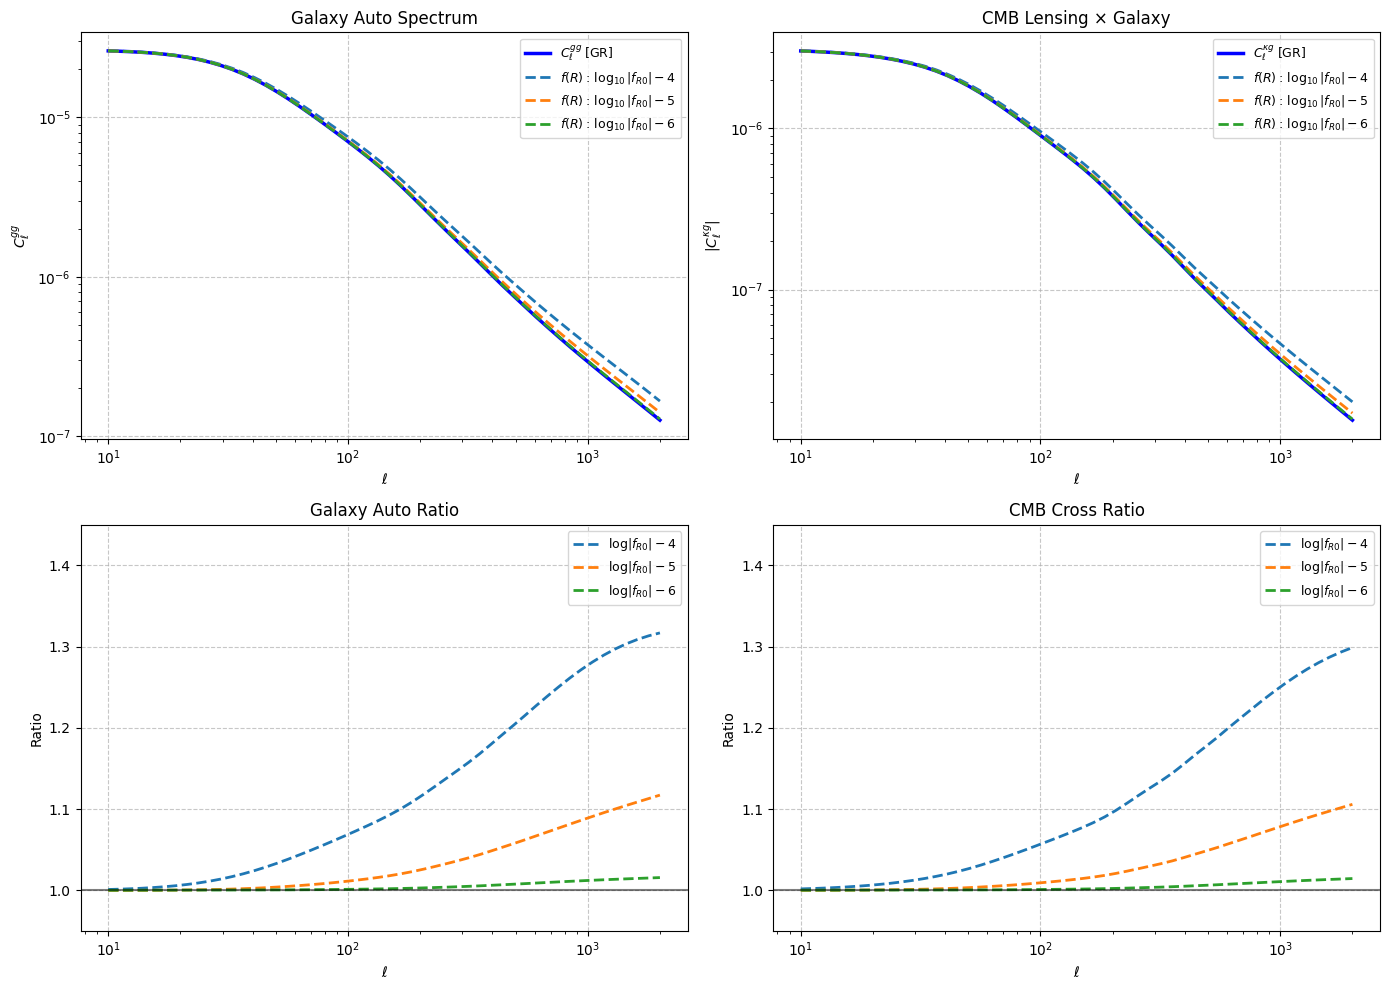

In [59]:
def plot_power_spectra(ell, Cl_gg_gr, Cl_kg_gr, fr_results=None,
                       fR_values=None, figsize=(14, 10)):
    fig = plt.figure(figsize=figsize)

    plt.subplot(2, 2, 1)
    plt.loglog(ell, Cl_gg_gr, "b-", linewidth=2.5, label=r"$C_\ell^{gg}\;[\mathrm{GR}]$")
    if fr_results and fR_values:
        for v in fR_values:
            if v in fr_results["gg"]:
                plt.loglog(ell, fr_results["gg"][v], "--", linewidth=2,
                           label=rf"$f(R):\,\log_{{10}}|f_{{R0}}|-{v}$")
    plt.xlabel(r"$\ell$"); plt.ylabel(r"$C_\ell^{gg}$")
    plt.title(r"Galaxy Auto Spectrum"); plt.legend(fontsize=9); plt.grid(ls="--", alpha=0.7)

    plt.subplot(2, 2, 2)
    plt.loglog(ell, np.abs(Cl_kg_gr), "b-", linewidth=2.5, label=r"$C_\ell^{\kappa g}\;[\mathrm{GR}]$")
    if fr_results and fR_values:
        for v in fR_values:
            if v in fr_results["kg"]:
                plt.loglog(ell, np.abs(fr_results["kg"][v]), "--", linewidth=2,
                           label=rf"$f(R):\,\log_{{10}}|f_{{R0}}|-{v}$")
    plt.xlabel(r"$\ell$"); plt.ylabel(r"$|C_\ell^{\kappa g}|$")
    plt.title(r"CMB Lensing × Galaxy"); plt.legend(fontsize=9); plt.grid(ls="--", alpha=0.7)

    plt.subplot(2, 2, 3)
    if fr_results and fR_values:
        for v in fR_values:
            if v in fr_results["gg"]:
                plt.semilogx(ell, fr_results["gg"][v] / Cl_gg_gr, "--", linewidth=2,
                             label=rf"$\log|f_{{R0}}|-{v}$")
        plt.axhline(1.0, color="k", lw=1.5, alpha=0.5)
    plt.xlabel(r"$\ell$"); plt.ylabel(r"Ratio"); plt.title(r"Galaxy Auto Ratio")
    plt.legend(fontsize=9); plt.grid(ls="--", alpha=0.7); plt.ylim([0.95, 1.45])

    plt.subplot(2, 2, 4)
    if fr_results and fR_values:
        for v in fR_values:
            if v in fr_results["kg"]:
                plt.semilogx(ell, fr_results["kg"][v] / Cl_kg_gr, "--", linewidth=2,
                             label=rf"$\log|f_{{R0}}|-{v}$")
        plt.axhline(1.0, color="k", lw=1.5, alpha=0.5)
    plt.xlabel(r"$\ell$"); plt.ylabel(r"Ratio"); plt.title(r"CMB Cross Ratio")
    plt.legend(fontsize=9); plt.grid(ls="--", alpha=0.7); plt.ylim([0.95, 1.45])

    plt.tight_layout()
    return fig


fig = plot_power_spectra(ell, Cl_gg_gr, Cl_kg_gr,
                         fr_results=fr_results, fR_values=Config.FR_VALUES,
                         figsize=Config.FIGURE_SIZE)
fig.savefig(os.path.join(PLOT_OUTPUT_DIR, "power_spectra_gr_vs_fr.png"), dpi=300, bbox_inches="tight")
plt.show()

## 13. MCMC Setup

In [60]:
PARAM_NAMES = [r"$\Omega_m$", r"$\sigma_8$", r"$b_0$", r"$\log_{10}|f_{R0}|$"]
FIDUCIAL_THETA = np.array([Config.COSMO_PARAMS["Omega_m"], Config.COSMO_PARAMS["sigma8"], Config.BIAS_B0, -5.0])
PRIORS = {"Omega_m": (0.20, 0.45), "sigma8": (0.60, 1.00), "b0": (0.50, 4.00), "logfR0": (-6.00, -4.00)}

N_Z_MCMC = 80
N_ELL_MCMC = 20
ELL_MIN_MCMC = Config.ELL_MIN
ELL_MAX_MCMC = 1200
STAT_FRAC_ERR_GG = 0.05
STAT_FRAC_ERR_KG = 0.08
N_WALKERS = 32
N_STEPS = 800
BURN_IN = 200
THIN = 5
HDF5_CHAIN_FILE = "emcee_clgg_clkg_chain.h5"
HDF5_BACKEND_NAME = "mcmc"
RESET_HDF5_BACKEND = True
CHECK_AUTOCORR_EVERY = 100

np.random.seed(42)

ell_mcmc = np.logspace(np.log10(ELL_MIN_MCMC), np.log10(ELL_MAX_MCMC), N_ELL_MCMC)
z_grid_mcmc = np.linspace(Config.Z_MIN, Config.Z_MAX, N_Z_MCMC)

### 13a. Time a single fiducial model evaluation

This is the inner loop of MCMC — knowing its cost is critical.

In [61]:
%%time
# First call builds caches — time it separately

Cl_gg_fid, Cl_kg_fid = model_cls_fast(
    FIDUCIAL_THETA,
    ell_mcmc,
    z_grid_mcmc,
    z_star,
    bacco_emu,
    emantis_emu,
    k,
    k_min_safe,
    k_max_safe,
)

CPU times: user 69 ms, sys: 14.9 ms, total: 84 ms
Wall time: 57.5 ms


In [62]:
%%timeit
# Subsequent calls hit the cache — timeit gives the cached cost

model_cls_fast(
    FIDUCIAL_THETA,
    ell_mcmc,
    z_grid_mcmc,
    z_star,
    bacco_emu,
    emantis_emu,
    k,
    k_min_safe,
    k_max_safe,
)

1.14 ms ± 53.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


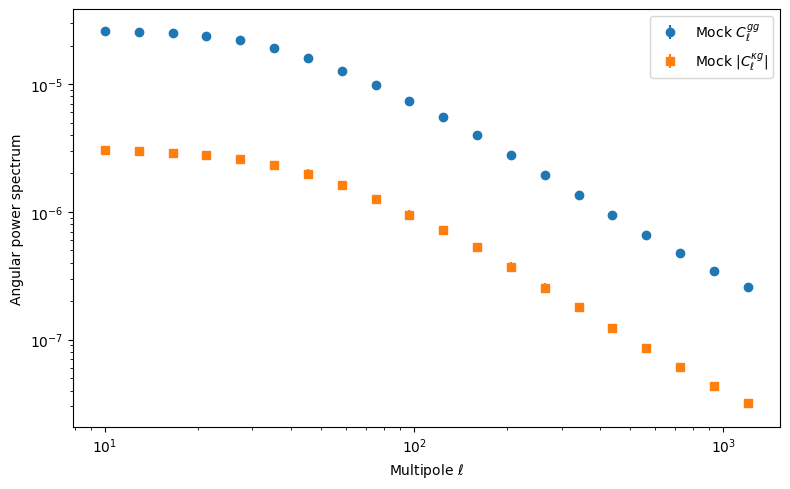

In [63]:
data_vector = flatten_cls(Cl_gg_fid, Cl_kg_fid)
sigma_gg = STAT_FRAC_ERR_GG * np.abs(Cl_gg_fid)
sigma_kg = STAT_FRAC_ERR_KG * np.maximum(np.abs(Cl_kg_fid), 1e-30)
sigma_vector = flatten_cls(sigma_gg, sigma_kg)

fig = plt.figure(figsize=(8, 5))
plt.errorbar(ell_mcmc, Cl_gg_fid, yerr=sigma_gg, fmt="o", label=r"Mock $C_\ell^{gg}$")
plt.errorbar(ell_mcmc, np.abs(Cl_kg_fid), yerr=sigma_kg, fmt="s", label=r"Mock $|C_\ell^{\kappa g}|$")
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"Multipole $\ell$"); plt.ylabel(r"Angular power spectrum")
plt.legend(); plt.tight_layout()
fig.savefig(os.path.join(PLOT_OUTPUT_DIR, "mock_data_vector.png"), dpi=300, bbox_inches="tight")
plt.show()

## 14. MCMC Log-Probability Functions

In [64]:
def log_prior(theta):
    Omega_m, sigma8, b0, logfR0 = theta
    if not (PRIORS["Omega_m"][0] < Omega_m < PRIORS["Omega_m"][1]): return -np.inf
    if not (PRIORS["sigma8"][0] < sigma8 < PRIORS["sigma8"][1]): return -np.inf
    if not (PRIORS["b0"][0] < b0 < PRIORS["b0"][1]): return -np.inf
    if not (PRIORS["logfR0"][0] < logfR0 < PRIORS["logfR0"][1]): return -np.inf
    return 0.0


def log_likelihood(theta):
    try:
        Cl_gg, Cl_kg = model_cls_fast(
            theta, ell_mcmc, z_grid_mcmc, z_star, bacco_emu, emantis_emu, k, k_min_safe, k_max_safe
        )
        model_vector = flatten_cls(Cl_gg, Cl_kg)
        if not np.all(np.isfinite(model_vector)):
            return -np.inf
        residual = (data_vector - model_vector) / sigma_vector
        return -0.5 * np.sum(residual ** 2)
    except Exception:
        return -np.inf


def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(theta)
    return lp + ll if np.isfinite(ll) else -np.inf

### 14a. Profile `log_probability` — the MCMC hot path

In [65]:
# Warm up cache first, then profile a fresh theta to see full cost
theta_test = np.array([0.31, 0.82, 1.9, -4.9])
%prun log_probability(theta_test)

         113935 function calls (109837 primitive calls) in 0.083 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
  3564/44    0.006    0.000    0.020    0.000 arrayprint.py:855(recurser)
     3520    0.006    0.000    0.008    0.000 arrayprint.py:1096(__call__)
     7040    0.004    0.000    0.004    0.000 {built-in method numpy._core._multiarray_umath.dragon4_positional}
        2    0.003    0.002    0.030    0.015 matter_powerspectrum.py:810(get_linear_pk)
    29890    0.003    0.000    0.003    0.000 {built-in method builtins.len}
     3520    0.002    0.000    0.003    0.000 arrayprint.py:805(_extendLine)
     3520    0.002    0.000    0.007    0.000 arrayprint.py:819(_extendLine_pretty)
      623    0.002    0.000    0.002    0.000 {built-in method numpy.array}
        1    0.002    0.002    0.051    0.051 matter_powerspectrum.py:272(_evaluate_nonlinear)
       85    0.002    0.000    0.003    0.000 kernels.py:1680(__

In [66]:
%lprun -f log_likelihood log_likelihood(theta_test)

Timer unit: 1e-09 s

Total time: 0.00302968 s
File: /tmp/ipykernel_906169/2563541817.py
Function: log_likelihood at line 10

Line #      Hits         Time  Per Hit   % Time  Line Contents
    10                                           def log_likelihood(theta):
    11         1        600.0    600.0      0.0      try:
    12         2    2987101.0 1.49e+06     98.6          Cl_gg, Cl_kg = model_cls_fast(
    13         1        710.0    710.0      0.0              theta, ell_mcmc, z_grid_mcmc, z_star, bacco_emu, emantis_emu, k, k_min_safe, k_max_safe
    14                                                   )
    15         1       7860.0   7860.0      0.3          model_vector = flatten_cls(Cl_gg, Cl_kg)
    16         1      16781.0  16781.0      0.6          if not np.all(np.isfinite(model_vector)):
    17                                                       return -np.inf
    18         1       2920.0   2920.0      0.1          residual = (data_vector - model_vector) / sigma_vect

# Profiling Table: Current Vectorized Run

| Rank | Operation / Cell | Current Run Output | Approx. Wall Time | Cost Level | Interpretation |
|---:|---|---:|---:|---|---|
| 1 | `build_pk_spline_gr(...)` | `Wall time: 1.52 s` | `1.52 s` | Highest | Main GR BACCO nonlinear power-spectrum spline construction. This is currently the most expensive standalone step. |
| 2 | First `model_cls_fast(...)` call | `Wall time: 882 ms` | `0.882 s` | Very high | First model call builds/caches the necessary spectra. Expensive because it performs fresh model construction. |
| 3 | `build_pk_splines_fr_many(...)` | `Wall time: 300 ms` | `0.300 s` | High | Builds all f(R) splines for `FR_VALUES = [4, 5, 6]` using vectorized BACCO + e-MANTIS. |
| 4 | Single `build_pk_spline_fr(...)` profile | `0.298 seconds` | `0.298 s` | High | Single f(R) spline construction. Similar to the all-f(R) vectorized timing, showing vectorization is working efficiently. |
| 5 | Fresh `log_probability(theta_test)` | `0.090 seconds` | `0.090 s` | Moderate | One fresh likelihood evaluation for a new MCMC parameter point. |
| 6 | `compute_Cl_vec(...)` with `%prun` | `0.018 seconds` | `18 ms` | Moderate-low | One angular power-spectrum calculation. Dominated by spline interpolation. |
| 7 | `compute_Cl_vec(...)` with `%timeit` | `9.99 ms ± 830 μs` | `~10 ms` | Moderate-low | Average runtime for one vectorized angular spectrum calculation. |
| 8 | Cached `model_cls_fast(...)` call | `1.07 ms ± 63.8 μs` | `~1.07 ms` | Low | Very fast because cached results are reused. |
| 9 | `galaxy_lensing_kernel_vec(...)` | `Total time: 0.000761 s` | `0.761 ms` | Very low | Galaxy lensing kernel calculation is cheap. |
| 10 | `build_window_interpolators(...)` | `568 μs ± 35.2 μs` | `0.568 ms` | Very low | Window/interpolator setup is not a bottleneck. |
| 11 | Geometry/background arrays | `75.4 μs ± 4.37 μs` | `0.075 ms` | Very low | Computes `chi_vals`, `H_vals`, `Wg_vals`, and `Wkappa_vals`; extremely cheap. |
| 12 | `initialize_bacco_emulator(...)` | `Wall time: 37.1 ms` | `37.1 ms` | Small one-time cost | Emulator initialization. Not a repeated bottleneck. |
| 13 | `initialize_emantis_emulator(...)` | `Wall time: 22.3 ms` | `22.3 ms` | Small one-time cost | e-MANTIS initialization. Not a repeated bottleneck. |


## Most-to-least expensive summary


| Order | Component | Time |
|---:|---|---:|
| 1 | GR spline construction with BACCO: `build_pk_spline_gr(...)` | `1.52 s` |
| 2 | First full model call: `model_cls_fast(...)` | `882 ms` |
| 3 | All f(R) spline construction: `build_pk_splines_fr_many(...)` | `300 ms` |
| 4 | Single f(R) spline: `build_pk_spline_fr(...)` | `298 ms` |
| 5 | Fresh MCMC likelihood: `log_probability(theta_test)` | `90 ms` |
| 6 | One angular spectrum: `compute_Cl_vec(...)` | `10–18 ms` |
| 7 | Cached model call: `model_cls_fast(...)` | `1.07 ms` |
| 8 | Galaxy lensing kernel: `galaxy_lensing_kernel_vec(...)` | `0.761 ms` |
| 9 | Window interpolator setup | `0.568 ms` |
| 10 | Geometry/background arrays | `0.075 ms` |


## Line-level bottleneck table


| Function | Dominant Line / Operation | % Time | Meaning |
|---|---|---:|---|
| `compute_Cl_vec(...)` | `pk_spline(...)` | `81.4%` | Most of the angular-spectrum time is spent evaluating the `RectBivariateSpline`. |
| `compute_Cl_vec(...)` | `np.clip(k_vals, k_min, k_max)` | `5.0%` | Small cost from keeping `k` inside emulator-safe range. |
| `compute_Cl_vec(...)` | `k_vals = (ell + 0.5) / chi_h` | `4.6%` | Vectorized Limber `k` calculation. |
| `compute_Cl_vec(...)` | `np.log(k_vals).ravel()` and `np.tile(...)` | `3.9%` | Preparing spline input arrays. |
| `compute_Cl_vec(...)` | `simpson(...)` | `2.9%` | Final redshift integration is cheap. |
| `log_likelihood(...)` | `model_cls_fast(...)` | `98.4%` | The likelihood is dominated by model prediction, not by chi-square calculation. |
| `log_likelihood(...)` | `flatten_cls(...)` | `0.3%` | Negligible. |
| `log_likelihood(...)` | residual calculation | `0.1%` | Negligible. |
| `log_likelihood(...)` | final `np.sum(residual ** 2)` | `0.5%` | Negligible. |
| `galaxy_lensing_kernel_vec(...)` | suffix integral `A_suffix` | `39.8%` | Main cost inside the lensing-kernel calculation. |
| `galaxy_lensing_kernel_vec(...)` | `chi_of_z(z_grid)` | `29.2%` | Interpolating comoving distance. |
| `galaxy_lensing_kernel_vec(...)` | suffix integral `B_suffix` | `17.1%` | Second cumulative integral. |


## Memory table


| Operation | Peak Memory | Increment | Interpretation |
|---|---:|---:|---|
| `build_pk_spline_gr(...)` with `%memit` | `488.80 MiB` | `0.00 MiB` | No large persistent memory increase detected in this run. |
| `compute_Cl_vec(...)` with `%memit` | `486.76 MiB` | `0.00 MiB` | Angular-spectrum calculation does not noticeably increase memory. |
| `compute_Cl_vec_mprun(...)` | `487.1 MiB` | `0.0 MiB` | Line-by-line memory remains flat. |
| `build_pk_spline_gr_mprun(...)` | `529.4 MiB` peak | `42.3 MiB` at BACCO call | Vectorized BACCO call temporarily increases memory by about `42.3 MiB`. |


## Final conclusion table

| Question | Answer |
|---|---|
| What is the slowest part in the current run? | `build_pk_spline_gr(...)`, taking about `1.52 s`. |
| What dominates the likelihood? | `model_cls_fast(...)`, taking `98.4%` of `log_likelihood(...)`. |
| What dominates `compute_Cl_vec(...)`? | `pk_spline(...)`, taking `81.4%`. |
| Is the redshift-loop emulator bottleneck still present? | No. It has been reduced by vectorized BACCO/e-MANTIS calls. |
| What is the new bottleneck after vectorization? | Power-spectrum spline construction and spline interpolation. |
| Is the current performance reasonable? | Yes. The code is now much better structured for MCMC. |